<a href="https://colab.research.google.com/github/np03cs4s240220-spec/2438438_Surajkiran_Shrestha_AI/blob/main/2438438_SurajkiranShrestha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sarcasm Detection in News Headlines
## 6CS012 - Final Integrated Assessment: Part III - Language Task

**Sentiment Analysis / Text Classification with RNN and LSTM**

This notebook implements an end-to-end NLP pipeline for sarcasm detection:
1. Text preprocessing, tokenization, and padding
2. Simple RNN with trainable embeddings
3. LSTM with trainable embeddings
4. LSTM with pre-trained Word2Vec (GloVe) embeddings
5. Evaluation and error analysis
6. GUI for real-time prediction


## 1. Setup and Installation

In [1]:
# Install required packages
!pip install numpy==1.23.5
!pip install gensim
!pip install wordcloud
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 25.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# IMPORTANT: After the installs above, restart runtime if prompted
# Then run this cell

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import time
import zipfile

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Dense,
                                      Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("All imports successful!")


TensorFlow: 2.20.0
GPU Available: []
All imports successful!


---
## 2. Data Loading and Exploration

### 2.1 Unzip and Load Dataset


In [5]:
import os
import zipfile
import pandas as pd

# ============================================================
# UPDATE THIS PATH to match YOUR Google Drive location
# ============================================================
ZIP_PATH = '/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/dataset/8. Sarcastic or Not Sarcastic Dataset-20260508T172612Z-3-001.zip'

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create extraction folder
EXTRACT_DIR = '/content/sarcasm_data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Unzip the dataset
print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Find the CSV file automatically
csv_path = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            break

print(f"Found CSV at: {csv_path}")

# Load the dataset
df = pd.read_csv(csv_path)
print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting dataset...
Found CSV at: /content/sarcasm_data/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv

Dataset loaded successfully!
Shape: (28619, 2)


In [6]:
# Dataset overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()


DATASET OVERVIEW
Shape: (28619, 2)
Columns: ['headline', 'is_sarcastic']

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [8]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/17dx66QDepLueVbrYsSTh1LhivQk-x7XI2UgXmUZjW4g/edit#gid=0


In [9]:
# Dataset statistics
print("\nDataset Info:")
print(f"  Total headlines: {len(df)}")
print(f"  Features: {df.columns.tolist()}")
print(f"  Missing values:\n{df.isnull().sum()}")
print(f"\nClass Distribution:")
print(df['is_sarcastic'].value_counts())
print(f"\nClass Proportions:")
print(df['is_sarcastic'].value_counts(normalize=True))



Dataset Info:
  Total headlines: 28619
  Features: ['headline', 'is_sarcastic']
  Missing values:
headline        0
is_sarcastic    0
dtype: int64

Class Distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Class Proportions:
is_sarcastic
0    0.523603
1    0.476397
Name: proportion, dtype: float64


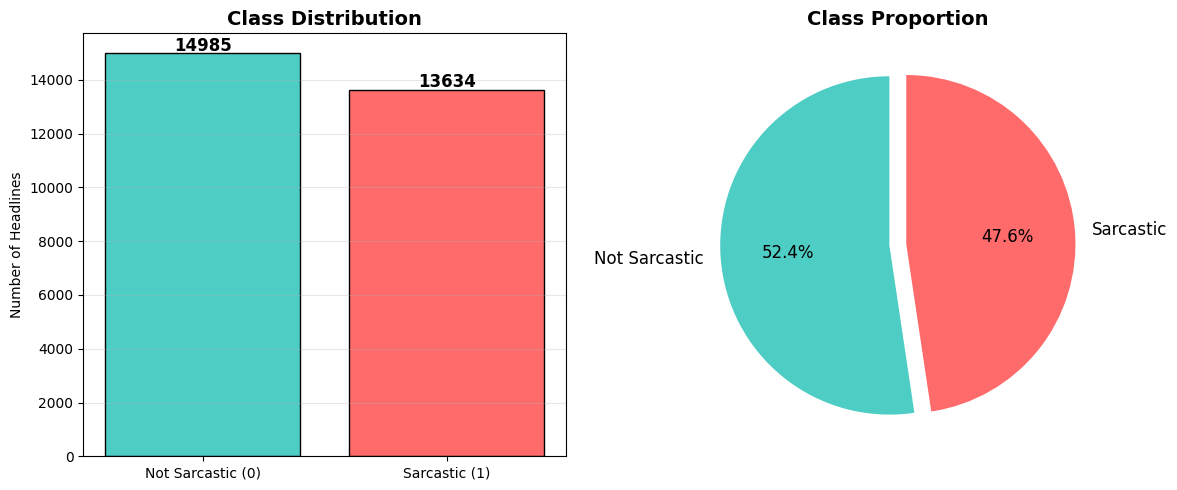


Sample Headlines:

Sarcastic examples:
  -> thirtysomething scientists unveil doomsday clock of hair loss
  -> inclement weather prevents liar from getting to work
  -> mother comes pretty close to using word 'streaming' correctly

Not Sarcastic examples:
  -> dem rep. totally nails why congress is falling short on gender, racial equality
  -> eat your veggies: 9 deliciously different recipes
  -> my white inheritance


In [10]:
# Visualize class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4ECDC4', '#FF6B6B']
counts = df['is_sarcastic'].value_counts()
bars = ax1.bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values, color=colors, edgecolor='black')
for bar, count in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
             str(count), ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Headlines')
ax1.grid(axis='y', alpha=0.3)

# Pie chart
ax2.pie(counts.values, labels=['Not Sarcastic', 'Sarcastic'],
        colors=colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12}, explode=(0.05, 0.05))
ax2.set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSample Headlines:")
print("\nSarcastic examples:")
for h in df[df['is_sarcastic']==1]['headline'].head(3).values:
    print(f"  -> {h}")
print("\nNot Sarcastic examples:")
for h in df[df['is_sarcastic']==0]['headline'].head(3).values:
    print(f"  -> {h}")


### 2.2 Text Length Analysis

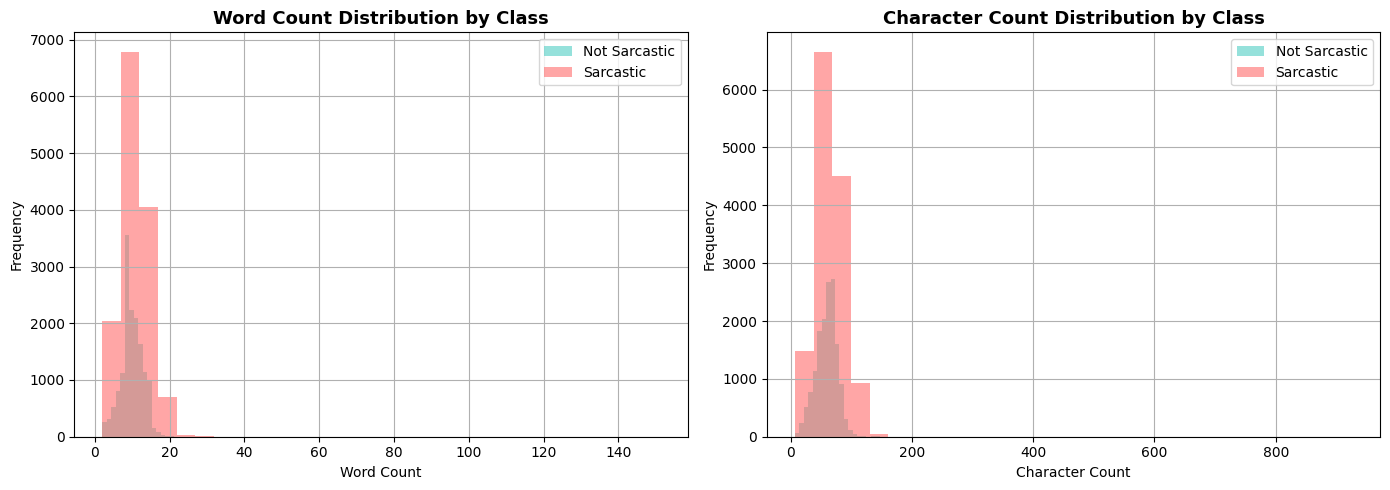


Word Count Stats:
                count       mean       std  min  25%   50%   75%    max
is_sarcastic                                                           
0             14985.0   9.815616  2.886045  2.0  8.0  10.0  12.0   38.0
1             13634.0  10.307540  3.849470  2.0  8.0  10.0  13.0  151.0


In [11]:
# Analyze text lengths
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(lambda x: len(str(x)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution by class
df[df['is_sarcastic']==0]['word_count'].hist(ax=ax1, bins=30, alpha=0.6, color='#4ECDC4', label='Not Sarcastic')
df[df['is_sarcastic']==1]['word_count'].hist(ax=ax1, bins=30, alpha=0.6, color='#FF6B6B', label='Sarcastic')
ax1.set_title('Word Count Distribution by Class', fontsize=13, fontweight='bold')
ax1.set_xlabel('Word Count')
ax1.set_ylabel('Frequency')
ax1.legend()

# Character count distribution
df[df['is_sarcastic']==0]['char_count'].hist(ax=ax2, bins=30, alpha=0.6, color='#4ECDC4', label='Not Sarcastic')
df[df['is_sarcastic']==1]['char_count'].hist(ax=ax2, bins=30, alpha=0.6, color='#FF6B6B', label='Sarcastic')
ax2.set_title('Character Count Distribution by Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Character Count')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nWord Count Stats:")
print(df.groupby('is_sarcastic')['word_count'].describe())


---
## 3. Text Preprocessing, Tokenization, and Sequence Padding

### 3.1 Text Cleaning


In [12]:
# Define contractions dictionary
contractions = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not", "didn't": "did not", "doesn't": "does not",
    "couldn't": "could not", "shouldn't": "should not", "wouldn't": "would not",
    "mustn't": "must not", "needn't": "need not",
    "i'm": "i am", "you're": "you are", "he's": "he is",
    "she's": "she is", "it's": "it is", "we're": "we are",
    "they're": "they are", "i've": "i have", "you've": "you have",
    "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "he'll": "he will",
    "she'll": "she will", "it'll": "it will", "we'll": "we will",
    "they'll": "they will", "i'd": "i would", "you'd": "you would",
    "he'd": "he would", "she'd": "she would", "we'd": "we would",
    "they'd": "they would", "that's": "that is", "who's": "who is",
    "what's": "what is", "here's": "here is", "there's": "there is",
    "where's": "where is", "how's": "how is", "let's": "let us",
}

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Handle contractions
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]

    return ' '.join(words)

# Apply cleaning
print("Cleaning text data...")
df['cleaned_text'] = df['headline'].apply(clean_text)

# Show before and after
print("\nSample Cleaning Results:")
print("=" * 80)
for i in range(5):
    print(f"\nOriginal:  {df['headline'].iloc[i]}")
    print(f"Cleaned:   {df['cleaned_text'].iloc[i]}")
    print("-" * 80)

# Remove empty rows after cleaning
df = df[df['cleaned_text'].str.strip().astype(bool)]
print(f"\nDataset size after cleaning: {len(df)}")


Cleaning text data...

Sample Cleaning Results:

Original:  thirtysomething scientists unveil doomsday clock of hair loss
Cleaned:   thirtysomething scientist unveil doomsday clock hair loss
--------------------------------------------------------------------------------

Original:  dem rep. totally nails why congress is falling short on gender, racial equality
Cleaned:   dem rep totally nail congress falling short gender racial equality
--------------------------------------------------------------------------------

Original:  eat your veggies: 9 deliciously different recipes
Cleaned:   eat veggie deliciously different recipe
--------------------------------------------------------------------------------

Original:  inclement weather prevents liar from getting to work
Cleaned:   inclement weather prevents liar getting work
--------------------------------------------------------------------------------

Original:  mother comes pretty close to using word 'streaming' correctly
Cleaned

### 3.2 Visualize Cleaned Data

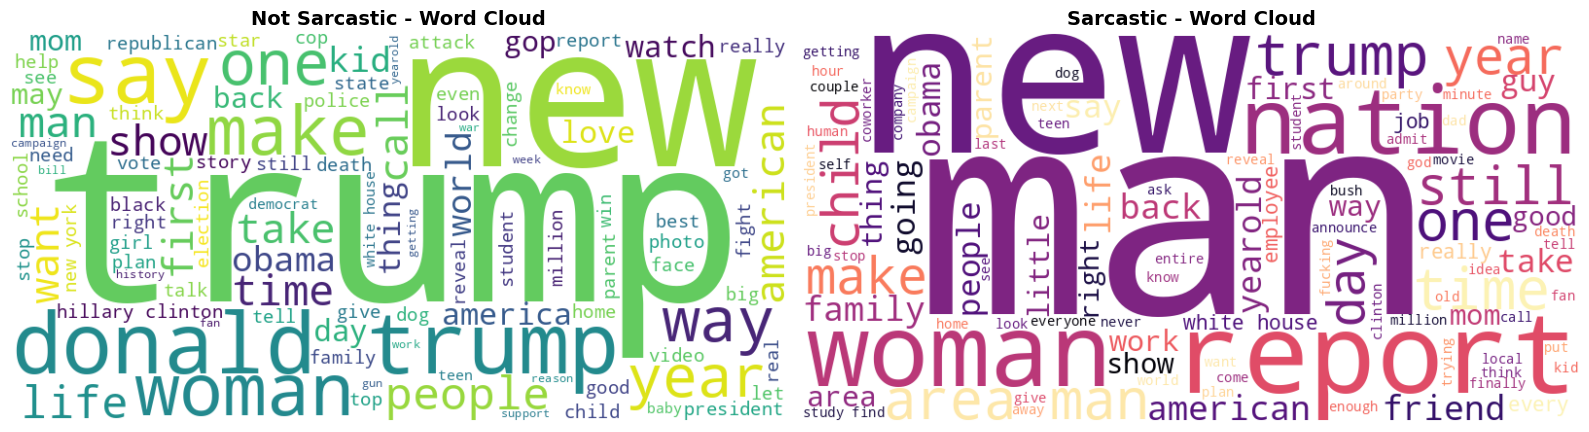

In [13]:
from wordcloud import WordCloud
from collections import Counter

# Word Cloud for each class
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Not Sarcastic word cloud
text_not_sarc = ' '.join(df[df['is_sarcastic']==0]['cleaned_text'])
wc1 = WordCloud(width=800, height=400, background_color='white',
                colormap='viridis', max_words=100).generate(text_not_sarc)
ax1.imshow(wc1, interpolation='bilinear')
ax1.set_title('Not Sarcastic - Word Cloud', fontsize=14, fontweight='bold')
ax1.axis('off')

# Sarcastic word cloud
text_sarc = ' '.join(df[df['is_sarcastic']==1]['cleaned_text'])
wc2 = WordCloud(width=800, height=400, background_color='white',
                colormap='magma', max_words=100).generate(text_sarc)
ax2.imshow(wc2, interpolation='bilinear')
ax2.set_title('Sarcastic - Word Cloud', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()


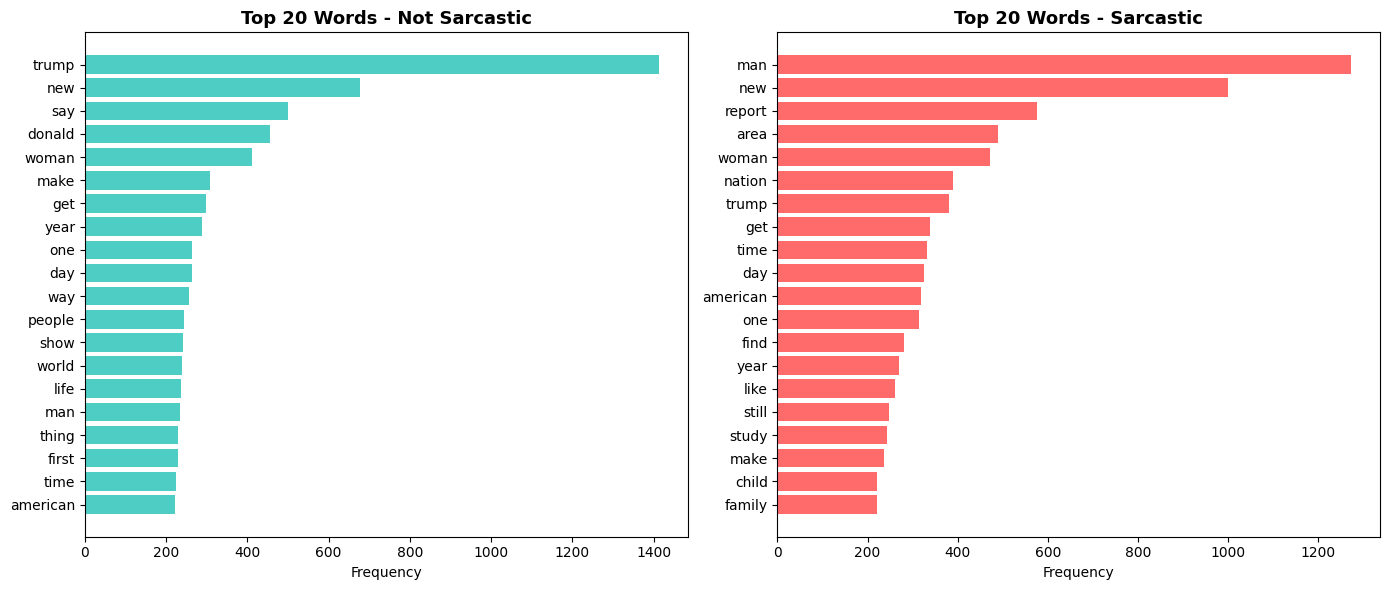

In [14]:
# Top 20 most frequent words per class
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Not Sarcastic
words_ns = Counter(' '.join(df[df['is_sarcastic']==0]['cleaned_text']).split())
common_ns = words_ns.most_common(20)
words_n, counts_n = zip(*common_ns)
ax1.barh(range(len(words_n)), counts_n, color='#4ECDC4')
ax1.set_yticks(range(len(words_n)))
ax1.set_yticklabels(words_n)
ax1.invert_yaxis()
ax1.set_title('Top 20 Words - Not Sarcastic', fontsize=13, fontweight='bold')
ax1.set_xlabel('Frequency')

# Sarcastic
words_s = Counter(' '.join(df[df['is_sarcastic']==1]['cleaned_text']).split())
common_s = words_s.most_common(20)
words_sa, counts_sa = zip(*common_s)
ax2.barh(range(len(words_sa)), counts_sa, color='#FF6B6B')
ax2.set_yticks(range(len(words_sa)))
ax2.set_yticklabels(words_sa)
ax2.invert_yaxis()
ax2.set_title('Top 20 Words - Sarcastic', fontsize=13, fontweight='bold')
ax2.set_xlabel('Frequency')

plt.tight_layout()
plt.show()


### 3.3 Tokenization and Padding

In [15]:
# Split data: 80% train, 20% test
X = df['cleaned_text']
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")
print(f"\nTrain class distribution: {Counter(y_train)}")
print(f"Test class distribution:  {Counter(y_test)}")


Training set: 22892 samples
Test set:     5724 samples

Train class distribution: Counter({np.int64(0): 11985, np.int64(1): 10907})
Test class distribution:  Counter({np.int64(0): 2997, np.int64(1): 2727})


Vocabulary Size: 22375

Sequence Length Statistics:
  Min: 1
  Max: 106
  Mean: 7.0
  Median: 7.0
  95th Percentile: 11

Chosen MAX_LENGTH (95th percentile): 11


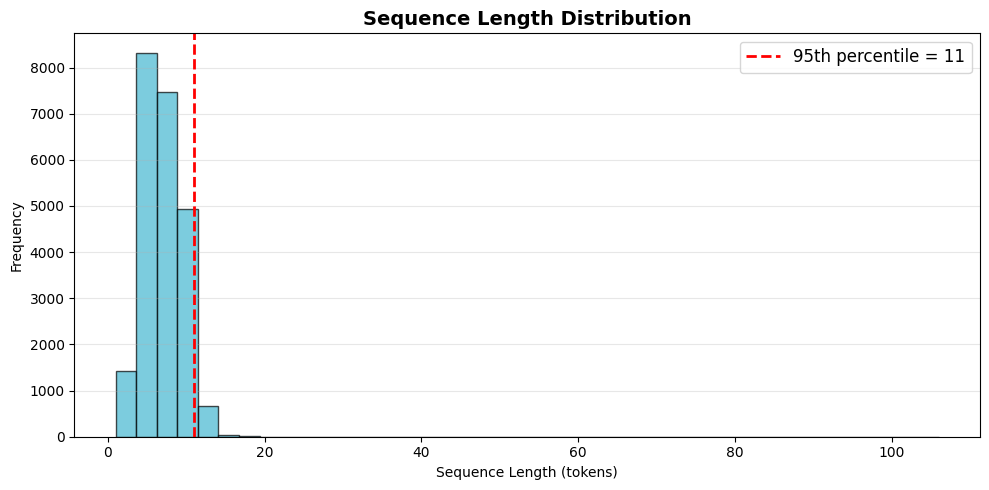

In [16]:
# Tokenization
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary Size: {vocab_size}")

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Analyze sequence lengths for percentile-based padding
seq_lengths = [len(seq) for seq in X_train_seq]
print(f"\nSequence Length Statistics:")
print(f"  Min: {min(seq_lengths)}")
print(f"  Max: {max(seq_lengths)}")
print(f"  Mean: {np.mean(seq_lengths):.1f}")
print(f"  Median: {np.median(seq_lengths):.1f}")
print(f"  95th Percentile: {np.percentile(seq_lengths, 95):.0f}")

# Use 95th percentile for max length
MAX_LENGTH = int(np.percentile(seq_lengths, 95))
print(f"\nChosen MAX_LENGTH (95th percentile): {MAX_LENGTH}")

# Visualize sequence length distribution
plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=40, color='#45B7D1', edgecolor='black', alpha=0.7)
plt.axvline(x=MAX_LENGTH, color='red', linestyle='--', linewidth=2, label=f'95th percentile = {MAX_LENGTH}')
plt.title('Sequence Length Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Frequency')
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# Apply padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"Padded training shape: {X_train_pad.shape}")
print(f"Padded test shape:     {X_test_pad.shape}")
print(f"\nSample padded sequence (first 20 tokens): {X_train_pad[0][:20]}")


Padded training shape: (22892, 11)
Padded test shape:     (5724, 11)

Sample padded sequence (first 20 tokens): [1365  101  599   38  323  831 3689    0    0    0    0]


---
## 4. Model Building and Training

### 4.1 Model 1: Simple RNN with Trainable Embedding


In [18]:
# Model 1: Simple RNN
EMBEDDING_DIM = 64

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=" * 60)
print("MODEL 1: Simple RNN")
print("=" * 60)
model_rnn.summary()


MODEL 1: Simple RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train Model 1
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1: Simple RNN...")
start_time = time.time()

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

rnn_time = time.time() - start_time
print(f"\nRNN Training Time: {rnn_time:.1f} seconds")


Training Model 1: Simple RNN...
Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7408 - loss: 0.5123 - val_accuracy: 0.7925 - val_loss: 0.4375
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9183 - loss: 0.2144 - val_accuracy: 0.7818 - val_loss: 0.5871
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9716 - loss: 0.0871 - val_accuracy: 0.7823 - val_loss: 0.7004
Epoch 4/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9848 - loss: 0.0452 - val_accuracy: 0.7578 - val_loss: 0.9553

RNN Training Time: 37.9 seconds


### 4.2 Model 2: LSTM with Trainable Embedding

In [20]:
# Model 2: LSTM
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=" * 60)
print("MODEL 2: LSTM")
print("=" * 60)
model_lstm.summary()


MODEL 2: LSTM


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train Model 2
print("Training Model 2: LSTM...")
start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

lstm_time = time.time() - start_time
print(f"\nLSTM Training Time: {lstm_time:.1f} seconds")


Training Model 2: LSTM...
Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.7313 - loss: 0.5197 - val_accuracy: 0.7934 - val_loss: 0.4392
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8889 - loss: 0.2775 - val_accuracy: 0.7886 - val_loss: 0.4860
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9466 - loss: 0.1511 - val_accuracy: 0.7744 - val_loss: 0.6495

LSTM Training Time: 30.4 seconds


### 4.3 Model 3: LSTM with Pre-trained Word2Vec (GloVe) Embeddings

In [22]:
# Load pre-trained GloVe embeddings
import gensim.downloader as api

print("Loading pre-trained GloVe embeddings (this may take a few minutes)...")
W2V_EMBEDDING_DIM = 100
embedding_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional
print(f"Loaded! Vocabulary size: {len(embedding_model)}")


Loading pre-trained GloVe embeddings (this may take a few minutes)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded! Vocabulary size: 400000


In [23]:
# Build embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, W2V_EMBEDDING_DIM))

found_count = 0
not_found_count = 0

for word, i in word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found_count += 1
    else:
        not_found_count += 1

print(f"Words found in GloVe: {found_count} ({found_count/len(word_index)*100:.1f}%)")
print(f"Words NOT found (will be zeros): {not_found_count} ({not_found_count/len(word_index)*100:.1f}%)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Words found in GloVe: 19574 (87.5%)
Words NOT found (will be zeros): 2800 (12.5%)
Embedding matrix shape: (22375, 100)


In [24]:
# Model 3: LSTM with pre-trained Word2Vec embeddings
model_w2v = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=W2V_EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LENGTH,
              trainable=False),  # Freeze pre-trained embeddings
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=" * 60)
print("MODEL 3: LSTM + Word2Vec (GloVe)")
print("=" * 60)
model_w2v.summary()


MODEL 3: LSTM + Word2Vec (GloVe)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,237,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,237,500 (8.54 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,237,500 (8.54 MB)

In [25]:
# Train Model 3
print("Training Model 3: LSTM + Word2Vec...")
start_time = time.time()

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

w2v_time = time.time() - start_time
print(f"\nLSTM + Word2Vec Training Time: {w2v_time:.1f} seconds")


Training Model 3: LSTM + Word2Vec...
Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6996 - loss: 0.5731 - val_accuracy: 0.7231 - val_loss: 0.5351
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7694 - loss: 0.4871 - val_accuracy: 0.7515 - val_loss: 0.5011
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7987 - loss: 0.4348 - val_accuracy: 0.7746 - val_loss: 0.4659

LSTM + Word2Vec Training Time: 18.7 seconds


---
## 5. Model Training and Evaluation

### 5.1 Training Curves Comparison


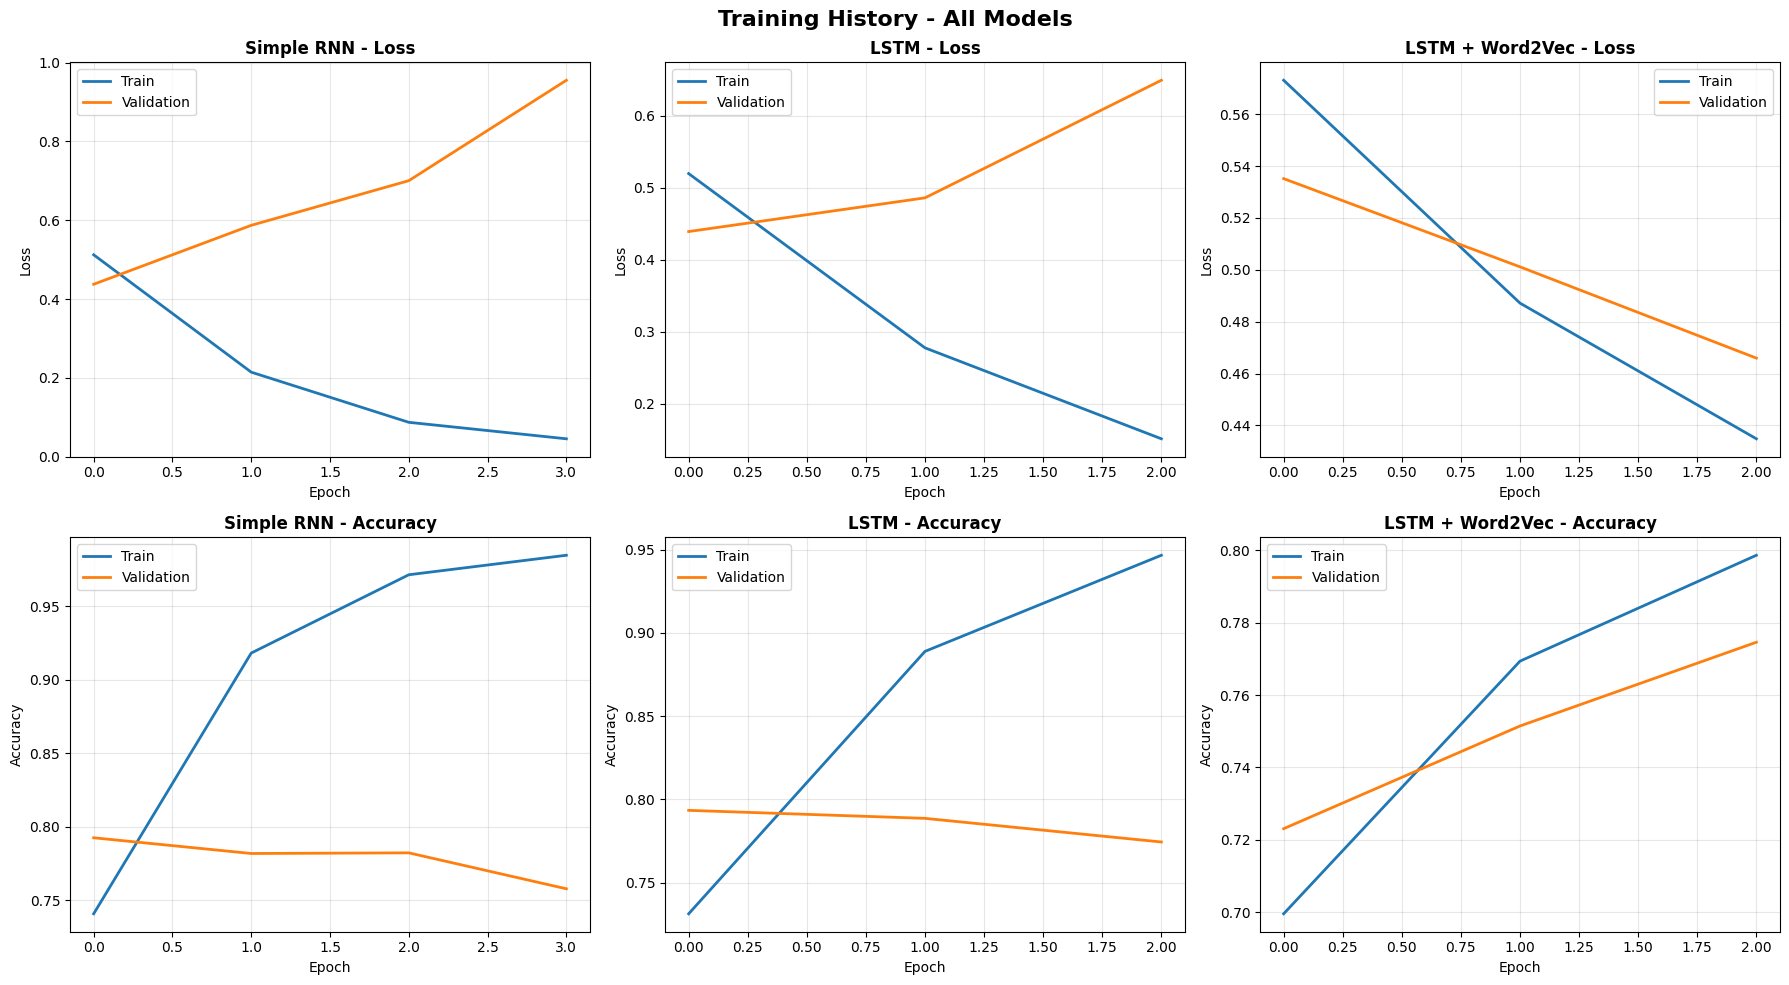

In [26]:
# Plot training curves for all three models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History - All Models', fontsize=16, fontweight='bold')

models_info = [
    ('Simple RNN', history_rnn),
    ('LSTM', history_lstm),
    ('LSTM + Word2Vec', history_w2v)
]

for idx, (name, history) in enumerate(models_info):
    # Loss
    axes[0, idx].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0, idx].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, idx].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

    # Accuracy
    axes[1, idx].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[1, idx].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[1, idx].set_title(f'{name} - Accuracy', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5.2 Model Comparison (Overlay)

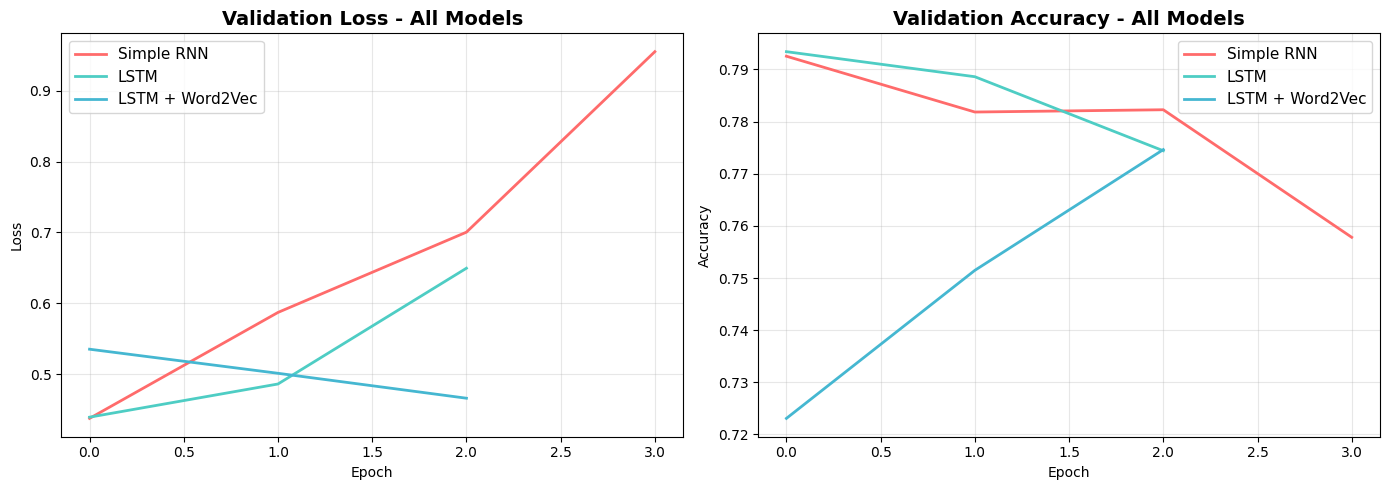

In [27]:
# Overlay comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for (name, history), color in zip(models_info, colors):
    ax1.plot(history.history['val_loss'], label=name, linewidth=2, color=color)
    ax2.plot(history.history['val_accuracy'], label=name, linewidth=2, color=color)

ax1.set_title('Validation Loss - All Models', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.set_title('Validation Accuracy - All Models', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5.3 Model Evaluation on Test Set

In [28]:
# Evaluate all models on test set
print("=" * 70)
print("MODEL EVALUATION ON TEST SET")
print("=" * 70)

results = {}

for name, model in [('Simple RNN', model_rnn), ('LSTM', model_lstm), ('LSTM + Word2Vec', model_w2v)]:
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': acc,
        'predictions': y_pred,
        'probabilities': y_pred_prob
    }

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Sarcastic', 'Sarcastic']))


MODEL EVALUATION ON TEST SET

Simple RNN
Test Accuracy: 0.8007 (80.07%)

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.78      0.87      0.82      2997
    Sarcastic       0.83      0.73      0.78      2727

     accuracy                           0.80      5724
    macro avg       0.81      0.80      0.80      5724
 weighted avg       0.80      0.80      0.80      5724


LSTM
Test Accuracy: 0.7926 (79.26%)

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.79      0.83      0.81      2997
    Sarcastic       0.80      0.76      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


LSTM + Word2Vec
Test Accuracy: 0.7343 (73.43%)

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.70      0.85      0.77     

### 5.4 Confusion Matrices

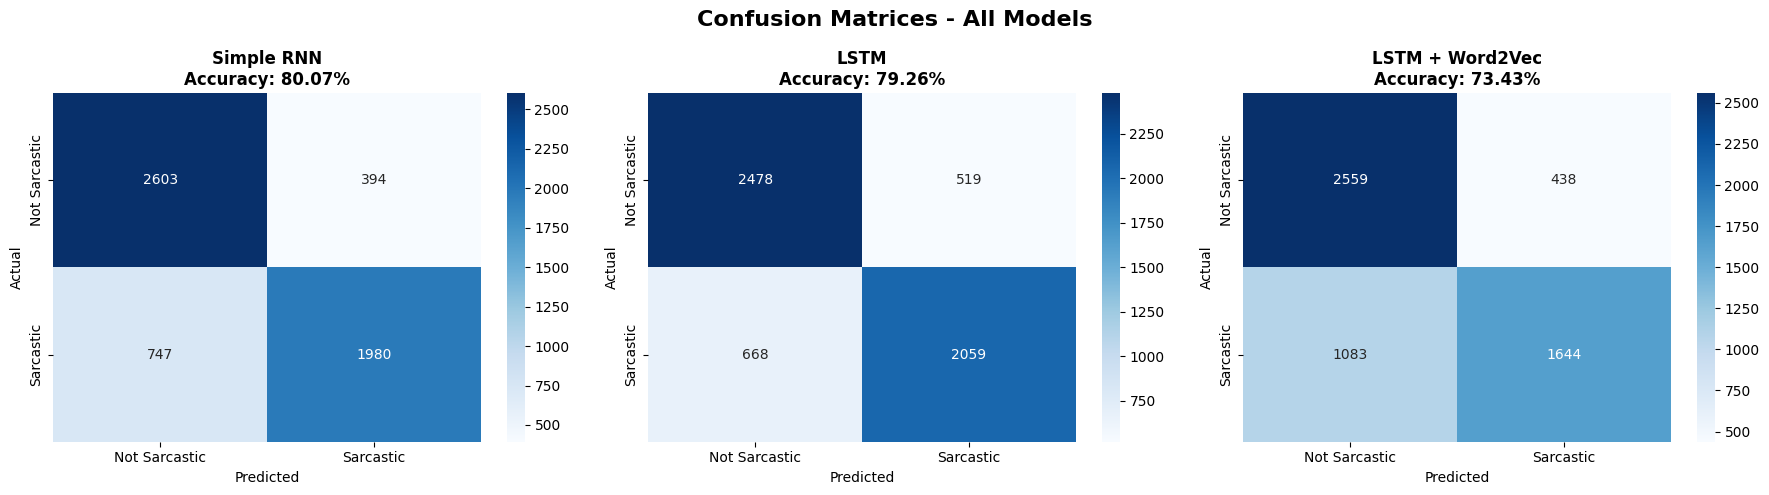

In [29]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Sarcastic', 'Sarcastic'],
                yticklabels=['Not Sarcastic', 'Sarcastic'])
    axes[idx].set_title(f'{name}\nAccuracy: {data["accuracy"]:.2%}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


### 5.5 Results Summary

COMPREHENSIVE RESULTS SUMMARY
Model                       Test Accuracy   Training Time
----------------------------------------------------------------------
Simple RNN                         0.8007          37.9s
LSTM                               0.7926          30.4s
LSTM + Word2Vec                    0.7343          18.7s
----------------------------------------------------------------------


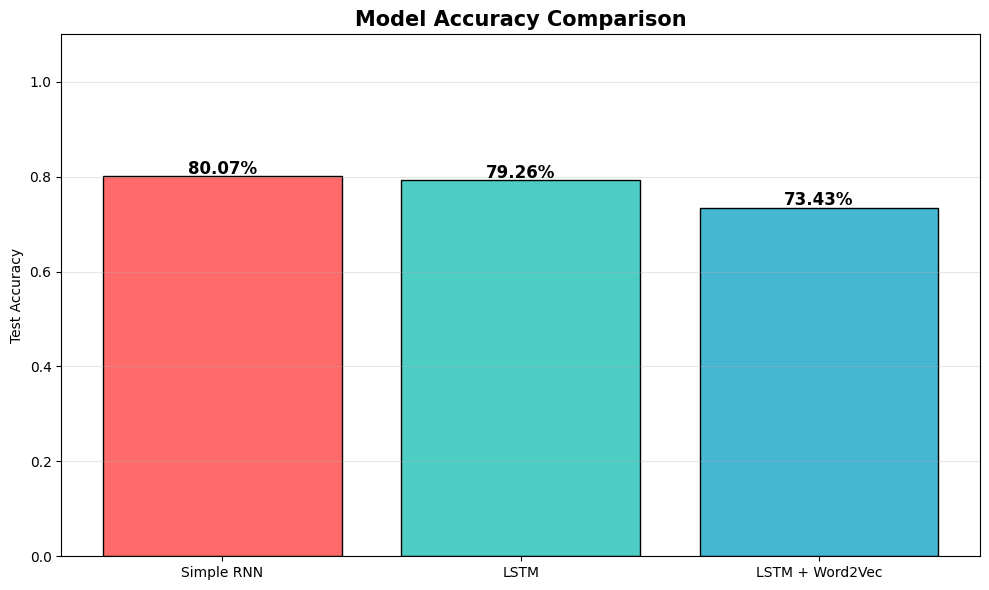


Best Performing Model: Simple RNN (80.07%)


In [30]:
# Final comparison table
print("=" * 70)
print("COMPREHENSIVE RESULTS SUMMARY")
print("=" * 70)
print(f"{'Model':<25} {'Test Accuracy':>15} {'Training Time':>15}")
print("-" * 70)
print(f"{'Simple RNN':<25} {results['Simple RNN']['accuracy']:>15.4f} {rnn_time:>13.1f}s")
print(f"{'LSTM':<25} {results['LSTM']['accuracy']:>15.4f} {lstm_time:>13.1f}s")
print(f"{'LSTM + Word2Vec':<25} {results['LSTM + Word2Vec']['accuracy']:>15.4f} {w2v_time:>13.1f}s")
print("-" * 70)

# Bar chart comparison
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold', fontsize=12)

plt.title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nBest Performing Model: {best_model_name} ({results[best_model_name]['accuracy']:.2%})")


---
## 6. Error Analysis

In [31]:
# Error Analysis - Find misclassified examples
best_model = model_lstm  # Use LSTM for analysis
best_model_name_ea = 'LSTM'

y_pred_prob_ea = best_model.predict(X_test_pad, verbose=0).flatten()
y_pred_ea = (y_pred_prob_ea > 0.5).astype(int)

# Get original texts for test set
X_test_texts = X_test.values

# Find misclassified samples
misclassified_mask = y_pred_ea != y_test
misclassified_indices = np.where(misclassified_mask)[0]

print("=" * 70)
print(f"ERROR ANALYSIS ({best_model_name_ea} Model)")
print("=" * 70)
print(f"Total test samples: {len(y_test)}")
print(f"Correct predictions: {np.sum(~misclassified_mask)}")
print(f"Misclassified: {np.sum(misclassified_mask)} ({np.mean(misclassified_mask)*100:.1f}%)")

print("\n" + "=" * 70)
print("SAMPLE MISCLASSIFIED HEADLINES")
print("=" * 70)

# Show 5 misclassified examples with analysis
for i, idx in enumerate(misclassified_indices[:5]):
    true_label = "Sarcastic" if y_test[idx] == 1 else "Not Sarcastic"
    pred_label = "Sarcastic" if y_pred_ea[idx] == 1 else "Not Sarcastic"
    confidence = y_pred_prob_ea[idx] if y_pred_ea[idx] == 1 else 1 - y_pred_prob_ea[idx]

    print(f"\nExample {i+1}:")
    print(f"  Headline:   {X_test_texts[idx]}")
    print(f"  True Label: {true_label}")
    print(f"  Predicted:  {pred_label} (confidence: {confidence:.2%})")
    print(f"  Raw Score:  {y_pred_prob_ea[idx]:.4f}")
    print("-" * 70)


ERROR ANALYSIS (LSTM Model)
Total test samples: 5724
Correct predictions: 4537
Misclassified: 1187 (20.7%)

SAMPLE MISCLASSIFIED HEADLINES

Example 1:
  Headline:   lady gaga rock god cover new single perfect illusion
  True Label: Not Sarcastic
  Predicted:  Sarcastic (confidence: 76.94%)
  Raw Score:  0.7694
----------------------------------------------------------------------

Example 2:
  Headline:   detroitarea resident demand clean air
  True Label: Not Sarcastic
  Predicted:  Sarcastic (confidence: 85.70%)
  Raw Score:  0.8570
----------------------------------------------------------------------

Example 3:
  Headline:   line cook learns leaving restaurant industry easy
  True Label: Sarcastic
  Predicted:  Not Sarcastic (confidence: 72.50%)
  Raw Score:  0.2750
----------------------------------------------------------------------

Example 4:
  Headline:   gay war hero awarded posthumous dishonorable discharge white house ceremony
  True Label: Sarcastic
  Predicted:  Not Sar

In [32]:
# Error type analysis
false_positives = np.sum((y_pred_ea == 1) & (y_test == 0))
false_negatives = np.sum((y_pred_ea == 0) & (y_test == 1))
true_positives = np.sum((y_pred_ea == 1) & (y_test == 1))
true_negatives = np.sum((y_pred_ea == 0) & (y_test == 0))

print("Error Type Breakdown:")
print(f"  True Positives (correctly identified sarcasm):  {true_positives}")
print(f"  True Negatives (correctly identified non-sarc): {true_negatives}")
print(f"  False Positives (incorrectly flagged as sarc):  {false_positives}")
print(f"  False Negatives (missed sarcasm):               {false_negatives}")

print("\nPossible Reasons for Misclassification:")
print("  1. Sarcasm relies on context, tone, and cultural knowledge that text alone may not capture")
print("  2. Some headlines are ambiguous - even humans may disagree on sarcasm")
print("  3. Short headlines provide limited context for the model")
print("  4. Words not in training vocabulary (OOV tokens) lose meaning")
print("  5. Subtle sarcasm without explicit markers is harder to detect")

print("\nPotential Improvements:")
print("  1. Use bidirectional LSTM to capture context from both directions")
print("  2. Increase embedding dimensions or use larger pre-trained embeddings")
print("  3. Add attention mechanism to focus on key sarcasm-indicating words")
print("  4. Use transformer-based models (BERT) for better contextual understanding")
print("  5. Augment training data with more diverse sarcasm examples")


Error Type Breakdown:
  True Positives (correctly identified sarcasm):  2059
  True Negatives (correctly identified non-sarc): 2478
  False Positives (incorrectly flagged as sarc):  519
  False Negatives (missed sarcasm):               668

Possible Reasons for Misclassification:
  1. Sarcasm relies on context, tone, and cultural knowledge that text alone may not capture
  2. Some headlines are ambiguous - even humans may disagree on sarcasm
  3. Short headlines provide limited context for the model
  4. Words not in training vocabulary (OOV tokens) lose meaning
  5. Subtle sarcasm without explicit markers is harder to detect

Potential Improvements:
  1. Use bidirectional LSTM to capture context from both directions
  2. Increase embedding dimensions or use larger pre-trained embeddings
  3. Add attention mechanism to focus on key sarcasm-indicating words
  4. Use transformer-based models (BERT) for better contextual understanding
  5. Augment training data with more diverse sarcasm e

### 6.1 Confidence Distribution Analysis

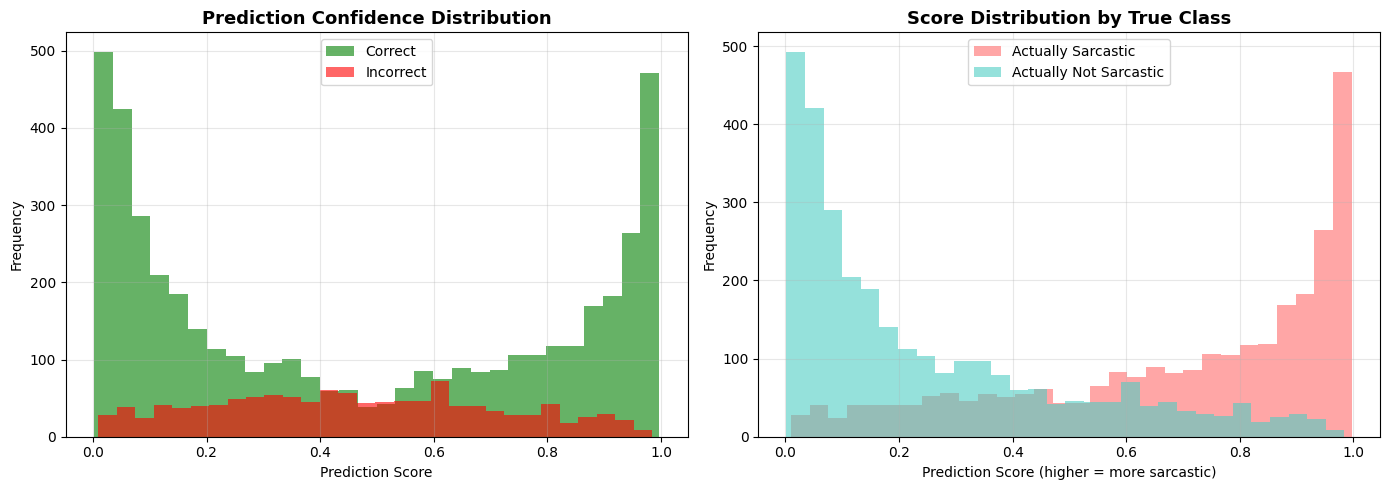

In [33]:
# Analyze prediction confidence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confidence for correct vs incorrect predictions
correct_conf = y_pred_prob_ea[~misclassified_mask]
incorrect_conf = y_pred_prob_ea[misclassified_mask]

ax1.hist(correct_conf, bins=30, alpha=0.6, color='green', label='Correct')
ax1.hist(incorrect_conf, bins=30, alpha=0.6, color='red', label='Incorrect')
ax1.set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Prediction Score')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Confidence by true class
sarc_scores = y_pred_prob_ea[y_test == 1]
non_sarc_scores = y_pred_prob_ea[y_test == 0]

ax2.hist(sarc_scores, bins=30, alpha=0.6, color='#FF6B6B', label='Actually Sarcastic')
ax2.hist(non_sarc_scores, bins=30, alpha=0.6, color='#4ECDC4', label='Actually Not Sarcastic')
ax2.set_title('Score Distribution by True Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Prediction Score (higher = more sarcastic)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. GUI for Real-Time Prediction

In [34]:
# Simple GUI using Gradio
import gradio as gr

def predict_sarcasm(headline):
    """Predict if a headline is sarcastic or not."""
    # Clean the input
    cleaned = clean_text(headline)

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

    # Predict with all three models
    results_text = ""

    for name, model in [('Simple RNN', model_rnn), ('LSTM', model_lstm), ('LSTM + Word2Vec', model_w2v)]:
        pred = model.predict(padded, verbose=0)[0][0]
        label = "SARCASTIC" if pred > 0.5 else "NOT SARCASTIC"
        confidence = pred if pred > 0.5 else 1 - pred
        results_text += f"{name}: {label} (Confidence: {confidence:.1%})\n"

    return results_text

# Create Gradio interface
interface = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(
        placeholder="Enter a headline to check for sarcasm...",
        label="News Headline",
        lines=2
    ),
    outputs=gr.Textbox(label="Prediction Results"),
    title="Sarcasm Detection in News Headlines",
    description="Enter a news headline to predict whether it is sarcastic or not. Uses RNN, LSTM, and LSTM+Word2Vec models.",
    examples=[
        ["area man passionate defender of what he imagines constitution to be"],
        ["new study finds connection between diet and health"],
        ["nation celebrates full week without mass shooting"],
        ["scientists discover high correlation between eating food and not being hungry"],
    ],
    theme="default"
)

# Launch (in Colab, this creates a public link)
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2e37fce59ccb74653b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 8. Summary and Conclusions

### Key Findings:
1. **LSTM outperforms Simple RNN** due to its ability to capture long-range dependencies and mitigate the vanishing gradient problem.
2. **Pre-trained Word2Vec embeddings** can provide a performance boost by starting with meaningful word representations.
3. **Sarcasm detection is inherently challenging** because sarcasm relies on context, tone, and cultural understanding.

### Model Comparison Summary:
| Model | Key Advantage | Key Limitation |
|-------|--------------|----------------|
| Simple RNN | Fast training, simple architecture | Struggles with long sequences (vanishing gradients) |
| LSTM | Handles long-term dependencies | More parameters, slower training |
| LSTM + Word2Vec | Leverages pre-trained word knowledge | OOV words get zero vectors |

### Future Improvements:
- Bidirectional LSTM for capturing context from both directions
- Attention mechanisms to focus on sarcasm-indicating words
- Transformer-based models (BERT, RoBERTa) for superior contextual understanding
- Cross-validation for more robust performance estimates
